#ANÁLISIS DATASET CONECTIVIDAD (CABOTAJE E INTERNACIONAL)

In [27]:
from pathlib import Path
from math import comb, exp, factorial
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import binom

try:
    from IPython.display import display
except ImportError:
    display = print

Carga e inspección de datasets

Primero cargamos los datos de conectividad aérea. Estos archivos ya vienen agregados por día, ruta, aerolínea, pasajeros, asientos y vuelos.

In [28]:
#Lista de archivos requeridos

ARCHIVOS_REQUERIDOS = [
    'conectividad_aerea_cabotaje.csv',
    'conectividad_aerea_internacional.csv',
    '202512-informe-ministerio-actualizado-dic-final.csv',
    '202604-informe-ministerio.csv',
    'failbondi-2026-05-20-dump.json',
]

#Búsqueda automática de los datasets
def resolver_data_dir():
    #Lista de carpetas candidatas
    candidatos = [
        Path.cwd() / 'datasets',
        Path.cwd(),
        Path.cwd().parent / 'datasets',  
        Path.cwd() / '4' / 'datasets',
        Path('/content') / 'datasets',
        Path('/content'),
        Path('/content/4') / 'datasets',
        Path('/content/drive/MyDrive/Matematica IV/4') / 'datasets',
        Path('/content/drive/MyDrive/Matematica_IV/4') / 'datasets',
        Path.cwd() / 'MateIV_Transporte_Publico' / 'datasets'
    ]

    for data_dir in candidatos:
        if data_dir.exists() and all((data_dir / archivo).exists() for archivo in ARCHIVOS_REQUERIDOS):
            return data_dir

    raise FileNotFoundError(
        'No se encontraron todos los datasets.'
    )

#Ruta a los dataset
DATA_DIR = resolver_data_dir()

#Ruta a la carpeta principal del proyecto
BASE_DIR = DATA_DIR.parent if DATA_DIR.name == 'datasets' else DATA_DIR

#Obtener los nombres de los archivos
archivos = sorted(p.name for p in DATA_DIR.iterdir())
print('Carpeta de datasets:', DATA_DIR)
print('Datasets encontrados:')
for nombre in archivos:
    print('-', nombre)

Carpeta de datasets: /home/charita/Documentos/UNRN/MATE4/MateIV_Transporte_Publico/datasets
Datasets encontrados:
- 202512-informe-ministerio-actualizado-dic-final.csv
- 202604-informe-ministerio.csv
- conectividad_aerea_cabotaje.csv
- conectividad_aerea_internacional.csv
- failbondi-2026-05-20-dump.json


In [29]:
MESES = {
    'Enero': 1,
    'Febrero': 2,
    'Marzo': 3,
    'Abril': 4,
    'Mayo': 5,
    'Junio': 6,
    'Julio': 7,
    'Agosto': 8,
    'Septiembre': 9,
    'Octubre': 10,
    'Noviembre': 11,
    'Diciembre': 12,
}


def leer_conectividad(nombre_archivo, clasificacion):
    df = pd.read_csv(DATA_DIR / nombre_archivo)
    df.columns = df.columns.str.strip()
    df['Clasificacion'] = clasificacion
    df['mes_num'] = df['Mes'].map(MESES)
    df['fecha'] = pd.to_datetime(
        dict(year=df['Año'], month=df['mes_num'], day=df['Dia']),
        errors='coerce'
    )
    df['ocupacion'] = np.where(df['Asientos'] > 0, df['Pasajeros'] / df['Asientos'], np.nan)
    return df

conectividad_cabotaje = leer_conectividad('conectividad_aerea_cabotaje.csv', 'Cabotaje')
conectividad_internacional = leer_conectividad('conectividad_aerea_internacional.csv', 'Internacional')
conectividad = pd.concat([conectividad_cabotaje, conectividad_internacional], ignore_index=True)


In [31]:
#INFORMACIÓN DEL DATASET DE CONECTIVIDAD (CABOTAJE + INTERNACIONAL)


print('-' * 100)
print("CANTIDAD DE FILAS DEL DATASET DE CONECTIVIDAD: CABOTAJE + INTERNACIONAL")
print('-' * 100)
print()
#Cantidad de filas del dataset
print('Filas cabotaje:', len(conectividad_cabotaje))
print('Filas internacional:', len(conectividad_internacional))
print('Filas totales:', len(conectividad))

#Conocer el rango temporal del dataset

fecha_inicio = conectividad['fecha'].min()
fecha_fin = conectividad['fecha'].max()

print()
print('-' * 100)
print("RANGO TEMPORAL DEL DATASET DE CONECTIVIDAD: CABOTAJE + INTERNACIONAL")
print('-' * 100)

print()
print("Fecha de inicio del dataset:", fecha_inicio.strftime('%d/%m/%Y'))
print("Fecha fin del dataset:", fecha_fin.strftime('%d/%m/%Y'))


print()
print('-' * 100)
print("INFORMACIÓN DEL DATASET DE CONECTIVIDAD: CABOTAJE + INTERNACIONAL")
print('-' * 100)
print()
#Obtener información del dataset
conectividad.info()

----------------------------------------------------------------------------------------------------
CANTIDAD DE FILAS DEL DATASET DE CONECTIVIDAD: CABOTAJE + INTERNACIONAL
----------------------------------------------------------------------------------------------------

Filas cabotaje: 446911
Filas internacional: 318422
Filas totales: 765333

----------------------------------------------------------------------------------------------------
RANGO TEMPORAL DEL DATASET DE CONECTIVIDAD: CABOTAJE + INTERNACIONAL
----------------------------------------------------------------------------------------------------

Fecha de inicio del dataset: 01/01/2019
Fecha fin del dataset: 30/04/2026

----------------------------------------------------------------------------------------------------
INFORMACIÓN DEL DATASET DE CONECTIVIDAD: CABOTAJE + INTERNACIONAL
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame

In [32]:
#Primeras cinco filas del dataset de conectividad
display(conectividad.head())

,Año,Mes,Dia,Clase de vuelo,Empresa agrupada,Empresa desagrupada,Ruta,Origen aeropuerto,Origen localidad,Origen provincia,...,Destino provincia,Destino país,Destino continente,Vuelos,Pasajeros,Asientos,Clasificacion,mes_num,fecha,ocupacion
0,2022,Febrero,22,Regular,Aerolíneas Argentinas,Aerolíneas Argentinas,Ciudad de Buenos Aires - Rosario,Aeropuerto Int. de Rosario Islas Malvinas,Rosario,Santa Fe,...,Ciudad Autónoma de Buenos Aires,Argentina,América del Sur,3,156,314,Cabotaje,2,2022-02-22,0.496815
1,2022,Febrero,22,Regular,Aerolíneas Argentinas,Aerolíneas Argentinas,Rosario - Salta,Aeropuerto Int. de Rosario Islas Malvinas,Rosario,Santa Fe,...,Salta,Argentina,América del Sur,1,93,96,Cabotaje,2,2022-02-22,0.968750
2,2022,Febrero,22,Regular,Aerolíneas Argentinas,Aerolíneas Argentinas,Mar del Plata - Rosario,Aeropuerto Int. de Rosario Islas Malvinas,Rosario,Santa Fe,...,Buenos Aires,Argentina,América del Sur,1,117,170,Cabotaje,2,2022-02-22,0.688235
3,2022,Febrero,22,Regular,Aerolíneas Argentinas,Aerolíneas Argentinas,Rosario - San Carlos de Bariloche,Aeropuerto Int. de Rosario Islas Malvinas,Rosario,Santa Fe,...,Río Negro,Argentina,América del Sur,1,69,170,Cabotaje,2,2022-02-22,0.405882
4,2022,Febrero,22,Regular,Aerolíneas Argentinas,Aerolíneas Argentinas,Ciudad de Buenos Aires - Rosario,Aeroparque Jorge Newbery,Buenos Aires,Ciudad Autónoma de Buenos Aires,...,Santa Fe,Argentina,América del Sur,3,174,362,Cabotaje,2,2022-02-22,0.480663


In [33]:
conectividad.describe()

,Año,Dia,Vuelos,Pasajeros,Asientos,mes_num,fecha,ocupacion
count,765333.000000,765333.000000,765333.000000,765333.000000,765333.000000,765333.000000,765333,765257.000000
mean,2022.527694,15.642907,1.628466,222.297471,267.243744,6.182225,2022-12-31 06:43:28.342250752,0.811653
min,2019.000000,1.000000,1.000000,3.000000,0.000000,1.000000,2019-01-01 00:00:00,0.008621
25%,2021.000000,8.000000,1.000000,107.000000,165.000000,3.000000,2021-02-19 00:00:00,0.739583
50%,2023.000000,16.000000,1.000000,164.000000,189.000000,6.000000,2023-05-27 00:00:00,0.853616
75%,2024.000000,23.000000,2.000000,278.000000,340.000000,9.000000,2024-12-06 00:00:00,0.935714
max,2026.000000,31.000000,15.000000,2442.000000,2475.000000,12.000000,2026-04-30 00:00:00,1.520000
std,2.261927,8.770881,1.195082,181.489588,201.725118,3.618617,NaN,0.167271


In [34]:
print()
print('Nulos principales en conectividad:')
display(conectividad.isna().sum().sort_values(ascending=False))
print()



Nulos principales en conectividad:


Destino provincia      160195
Origen provincia       158221
Origen localidad          483
Destino localidad         437
ocupacion                  76
Año                         0
Dia                         0
Mes                         0
Origen aeropuerto           0
Ruta                        0
Empresa desagrupada         0
Empresa agrupada            0
Clase de vuelo              0
Origen continente           0
Destino aeropuerto          0
Origen país                 0
Destino país                0
Destino continente          0
Pasajeros                   0
Vuelos                      0
Asientos                    0
Clasificacion               0
mes_num                     0
fecha                       0
dtype: int64

Análisis de los valores nulos

In [35]:
# ¿La ocupación tiene 76 filas nulas porque en esas filas los asientos son 0?
# La función devuelve true en caso verdadero
(
    conectividad.loc[conectividad["ocupacion"].isna(), "Asientos"] == 0
).all()



np.True_

In [36]:
#¿Las 160.195 filas de la columna DESTINO PROVINCIA son nulas porque el vuelo es internacional?
#La función devuelve un booleano.
(
    conectividad.loc[
        conectividad["Destino provincia"].isna(),
        "Clasificacion"
    ] == "Internacional"
).all()

np.True_

In [37]:
#¿Las 158.221 filas de la columna ORIGEN PROVINCIA son nulas porque el vuelo es internacional?
#La función devuelve un booleano.
(
    conectividad.loc[
        conectividad["Origen provincia"].isna(),
        "Clasificacion"
    ] == "Internacional"
).all()

np.True_

In [38]:
#¿Qué clasificación de vuelos generan que el ORIGEN LOCALIDAD sea nulo?
conectividad.loc[
    conectividad["Origen localidad"].isna(),
    "Clasificacion"
].value_counts()

Clasificacion
Internacional    437
Cabotaje          46
Name: count, dtype: int64

In [39]:
# ¿Cuál es la provincia de origen cuyo origen localidad tiene 46 filas nulas?

cabotaje_nulos = conectividad.loc[
    (conectividad["Origen localidad"].isna()) &
    (conectividad["Clasificacion"] == "Cabotaje")
]

cabotaje_nulos["Origen provincia"].value_counts(dropna=False)


Origen provincia
Tierra del Fuego, Antártida e Islas del Atlántico Sur    46
Name: count, dtype: int64

In [40]:
# Cuál es el AEROPUERTO DE ORIGEN de esas 46 filas cuya localidad es nula?
cabotaje_nulos["Origen aeropuerto"].value_counts(dropna=False)

Origen aeropuerto
Islas Malvinas    46
Name: count, dtype: int64

In [41]:
# Cuál es la provincia de origen que da 3 filas nulas en vuelos internacionales con origen localidad nulo?


internacional_nulos = conectividad.loc[
    (conectividad["Origen localidad"].isna()) &
    (conectividad["Clasificacion"] == "Internacional")
]

internacional_nulos["Origen provincia"].value_counts(dropna=False)

Origen provincia
NaN                                                      434
Tierra del Fuego, Antártida e Islas del Atlántico Sur      3
Name: count, dtype: int64

In [42]:
#Esos tres vuelos de Tierra del Fuego son nulos en la localidad porque provienen de Islas Malvinas?

len(conectividad.loc[
    (conectividad["Origen localidad"].isna()) &
    (conectividad["Origen provincia"] == "Tierra del Fuego, Antártida e Islas del Atlántico Sur") &
    (conectividad["Clasificacion"] == "Internacional")
])

3

In [43]:
#Cuál es la clasificación del vuelo que tiene 437 nulos en DESTINO LOCALIDAD?

conectividad.loc[
    conectividad["Destino localidad"].isna(),
    "Clasificacion"
].value_counts()

Clasificacion
Internacional    385
Cabotaje          52
Name: count, dtype: int64

In [44]:
#Esos 385 vuelos internacionales que tienen en destino localidad nulos, también lo son en la provincia?


internacional_nulos = conectividad.loc[
    (conectividad["Destino localidad"].isna()) &
    (conectividad["Clasificacion"] == "Internacional")
]

internacional_nulos["Destino provincia"].value_counts(dropna=False)

Destino provincia
NaN                                                      382
Tierra del Fuego, Antártida e Islas del Atlántico Sur      3
Name: count, dtype: int64

In [45]:
#Esos tres vuelos de Tierra del Fuego son nulos en la localidad destino porque provienen de Islas Malvinas?

len(internacional_nulos.loc[
    (internacional_nulos["Destino localidad"].isna()) &
    (internacional_nulos["Destino provincia"] == "Tierra del Fuego, Antártida e Islas del Atlántico Sur") &
    (internacional_nulos["Clasificacion"] == "Internacional")
])

3

In [46]:
# Filas de cabotaje con DESTINO LOCALIDAD nulo

cabotaje_nulos = conectividad.loc[
    (conectividad["Destino localidad"].isna()) &
    (conectividad["Clasificacion"] == "Cabotaje")
]

# Que provincia es la de la localidad que da nulo?
cabotaje_nulos["Destino provincia"].value_counts(dropna=False)

Destino provincia
Tierra del Fuego, Antártida e Islas del Atlántico Sur    52
Name: count, dtype: int64

In [47]:
#Esos 52 vuelos de Tierra del Fuego son nulos en la localidad porque provienen de Islas Malvinas?

len(cabotaje_nulos.loc[
    (cabotaje_nulos["Destino localidad"].isna()) &
    (cabotaje_nulos["Destino provincia"] == "Tierra del Fuego, Antártida e Islas del Atlántico Sur") &
    (cabotaje_nulos["Clasificacion"] == "Cabotaje")
])

52

##Pre-Conclusión del análisis de nulos en Conectividad

En conjunto, los nulos del dataset no son aleatorios ni problemáticos, sino que responden a tres patrones bien definidos:

Vuelos internacionales → no se computa la provincia de origen / destino. Casos especiales (Islas Malvinas / Tierra del Fuego) no se completa la localidad origen / destino Ocupación → Da nulo cuando el número de asientos es 0

##Análisis estadístico descriptivo

Se calculan totales y medidas resumen para comparar cabotaje e internacional.

In [48]:
resumen_conectividad = conectividad.groupby('Clasificacion').agg(
    vuelos=('Vuelos', 'sum'),
    pasajeros=('Pasajeros', 'sum'),
    asientos=('Asientos', 'sum'),
    ocupacion_promedio=('ocupacion', 'mean'),
    ocupacion_mediana=('ocupacion', 'median'),
    registros=('Ruta', 'count'),
).reset_index()
resumen_conectividad['ocupacion_promedio'] = resumen_conectividad['ocupacion_promedio'] * 100
resumen_conectividad['ocupacion_mediana'] = resumen_conectividad['ocupacion_mediana'] * 100

display(resumen_conectividad)

,Clasificacion,vuelos,pasajeros,asientos,ocupacion_promedio,ocupacion_mediana,registros
0,Cabotaje,787985,95117060,113020355,81.425757,85.338346,446911
1,Internacional,458334,75014530,91510101,80.799683,85.393258,318422


In [49]:
top_rutas = conectividad.groupby(['Clasificacion', 'Ruta']).agg(
    vuelos=('Vuelos', 'sum'),
    pasajeros=('Pasajeros', 'sum'),
    asientos=('Asientos', 'sum'),
).reset_index()
top_rutas['ocupacion'] = top_rutas['pasajeros'] / top_rutas['asientos']

display(top_rutas.sort_values('pasajeros', ascending=False).head(10))


,Clasificacion,Ruta,vuelos,pasajeros,asientos,ocupacion
42,Cabotaje,Ciudad de Buenos Aires - San Carlos de Bariloche,49340,7419737,8327601,0.890981
21,Cabotaje,Ciudad de Buenos Aires - Córdoba,54665,7250899,8484891,0.854566
27,Cabotaje,Ciudad de Buenos Aires - Mendoza,51294,6855503,7940252,0.863386
32,Cabotaje,Ciudad de Buenos Aires - Puerto Iguazú,41061,5796423,6604628,0.877631
581,Internacional,Ezeiza - Madrid,19451,5496882,6168319,0.891147
469,Internacional,Ciudad de Buenos Aires - São Paulo,33629,4911109,5831186,0.842214
645,Internacional,Ezeiza - São Paulo,28812,4906795,6664186,0.736293
637,Internacional,Ezeiza - Santiago,29924,4581682,6062680,0.755719
41,Cabotaje,Ciudad de Buenos Aires - Salta,32324,4440652,5029121,0.882988
29,Cabotaje,Ciudad de Buenos Aires - Neuquén,31620,4412362,5077204,0.869054


  dia_semana  Pasajeros
0      Lunes   25004426
1     Martes   23015165
2  Miércoles   23260696
3     Jueves   24212589
4    Viernes   24868605
5     Sábado   24863596
6    Domingo   24906513

Mayor demanda: Lunes - 25,004,426 PAX
Menor demanda: Martes - 23,015,165 PAX


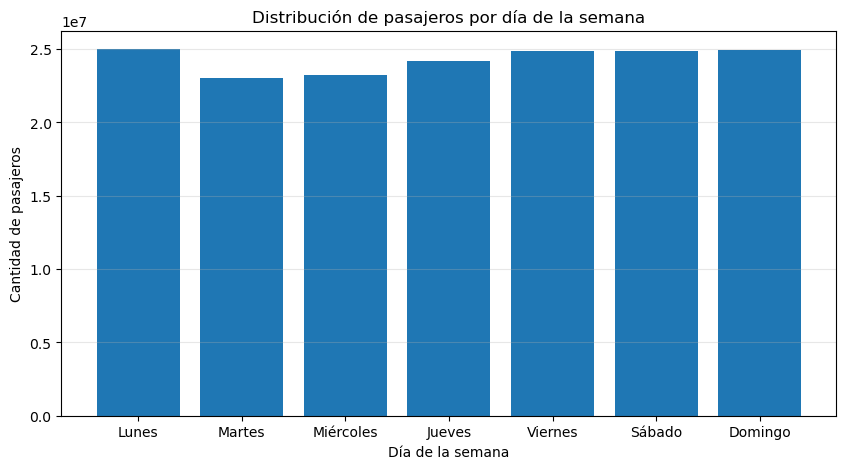

In [50]:
# Asegurar formato de fecha
conectividad['fecha'] = pd.to_datetime(conectividad['fecha'])

# Mapeo de días en inglés → español
map_dias = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

# Crear columna día de la semana
conectividad['dia_semana'] = conectividad['fecha'].dt.day_name().map(map_dias)

# Orden correcto de días
orden_dias = [
    'Lunes', 'Martes', 'Miércoles',
    'Jueves', 'Viernes', 'Sábado', 'Domingo'
]

# Total de pasajeros por día
pax_por_dia = (
    conectividad.groupby('dia_semana')['Pasajeros']
     .sum()
    .reindex(orden_dias)
    .reset_index()
)

print(pax_por_dia)

# Día con mayor y menor demanda
dia_max = pax_por_dia.loc[pax_por_dia['Pasajeros'].idxmax()]
dia_min = pax_por_dia.loc[pax_por_dia['Pasajeros'].idxmin()]

print(f"\nMayor demanda: {dia_max['dia_semana']} - {dia_max['Pasajeros']:,.0f} PAX")
print(f"Menor demanda: {dia_min['dia_semana']} - {dia_min['Pasajeros']:,.0f} PAX")

# Gráfico
plt.figure(figsize=(10,5))
plt.bar(pax_por_dia['dia_semana'], pax_por_dia['Pasajeros'])

plt.xlabel('Día de la semana')
plt.ylabel('Cantidad de pasajeros')
plt.title('Distribución de pasajeros por día de la semana')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [51]:
# Total de pasajeros por mes
conectividad2025 = conectividad[conectividad['Año'] == 2025]

# Orden
orden_meses = [
    'Enero', 'Febrero', 'Marzo', 'Abril',
    'Mayo', 'Junio', 'Julio', 'Agosto',
    'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'
]

# PAX por mes 
pax_por_mes = (
    conectividad2025.groupby('Mes')['Pasajeros']
    .sum()
    .reindex(orden_meses)
    .reset_index()
)

print(pax_por_mes)

# Mes máximo y mínimo
mes_max = pax_por_mes.loc[pax_por_mes['Pasajeros'].idxmax()]
mes_min = pax_por_mes.loc[pax_por_mes['Pasajeros'].idxmin()]

print(f"\nMayor demanda: {mes_max['Mes']} - {mes_max['Pasajeros']:,.0f} PAX")
print(f"Menor demanda: {mes_min['Mes']} - {mes_min['Pasajeros']:,.0f} PAX")

           Mes  Pasajeros
0        Enero    3036213
1      Febrero    2744335
2        Marzo    2939782
3        Abril    2521116
4         Mayo    2430575
5        Junio    2352264
6        Julio    2907681
7       Agosto    2809047
8   Septiembre    2656666
9      Octubre    2777870
10   Noviembre    2859096
11   Diciembre    3118609

Mayor demanda: Diciembre - 3,118,609 PAX
Menor demanda: Junio - 2,352,264 PAX


In [52]:
# Ocupación promedio por mes

ocupacion_por_mes = (
    conectividad2025.groupby('Mes')['ocupacion']
    .mean()
    .reset_index()
)

print(ocupacion_por_mes)

# Mes con mayor y menor ocupación
mes_max = ocupacion_por_mes.loc[ocupacion_por_mes['ocupacion'].idxmax()]
mes_min = ocupacion_por_mes.loc[ocupacion_por_mes['ocupacion'].idxmin()]

print(f"\nMayor ocupación 2025: {mes_max['Mes']} - {mes_max['ocupacion']:.2f}")
print(f"Menor ocupación 2025: {mes_min['Mes']} - {mes_min['ocupacion']:.2f}")

           Mes  ocupacion
0        Abril   0.820177
1       Agosto   0.797864
2    Diciembre   0.819240
3        Enero   0.839714
4      Febrero   0.850816
5        Julio   0.805371
6        Junio   0.785388
7        Marzo   0.824201
8         Mayo   0.798935
9    Noviembre   0.831517
10     Octubre   0.802360
11  Septiembre   0.797106

Mayor ocupación 2025: Febrero - 0.85
Menor ocupación 2025: Junio - 0.79


##Análisis de probabilidades

Se estiman probabilidades simples a partir de frecuencias observadas.

In [53]:
total_vuelos_conectividad = conectividad['Vuelos'].sum()

probabilidades = {
    'P(vuelo de cabotaje en conectividad)': conectividad.loc[conectividad['Clasificacion'] == 'Cabotaje', 'Vuelos'].sum() / total_vuelos_conectividad,
    'P(vuelo internacional en conectividad)': conectividad.loc[conectividad['Clasificacion'] == 'Internacional', 'Vuelos'].sum() / total_vuelos_conectividad,
    'P(clase regular en conectividad)': conectividad.loc[conectividad['Clase de vuelo'] == 'Regular', 'Vuelos'].sum() / total_vuelos_conectividad,
    'P(empresa Aerolineas en conectividad)': conectividad.loc[conectividad['Empresa agrupada'] == 'Aerolíneas Argentinas', 'Vuelos'].sum() / total_vuelos_conectividad,
    'P(ruta BUE/SCB en conectividad)': conectividad.loc[conectividad['Ruta'] == 'Ciudad de Buenos Aires - San Carlos de Bariloche', 'Vuelos'].sum() / total_vuelos_conectividad,
       
}

probabilidades_df = pd.DataFrame(
    [{'evento': evento, 'probabilidad': valor, 'porcentaje': valor * 100} for evento, valor in probabilidades.items()]
)
display(probabilidades_df)

,evento,probabilidad,porcentaje
0,P(vuelo de cabotaje en conectividad),0.632250,63.224985
1,P(vuelo internacional en conectividad),0.367750,36.775015
2,P(clase regular en conectividad),0.990230,99.023043
3,P(empresa Aerolineas en conectividad),0.533673,53.367316
4,P(ruta BUE/SCB en conectividad),0.039589,3.958858


# Probabilidad condicional

In [54]:
umbral = conectividad['Pasajeros'].quantile(0.75)
conectividad['alta_demanda'] = conectividad['Pasajeros'] > umbral

prob_viernes = conectividad[conectividad['dia_semana'] == 'Viernes']['alta_demanda'].mean()*100
print(prob_viernes)

25.34562211981567


# Distribuciones de probabilidad

    Binomial: si se miran 20 vuelos, ¿cuál es la probabilidad de que exactamente 5 estén demorados más de 15 minutos?
    Poisson: usando la media diaria de vuelos demorados, ¿cuál es la probabilidad de observar exactamente 10 demoras en un día?



In [55]:
conectividad['alta_ocupacion'] = conectividad['ocupacion'] > 0.8
p = conectividad['alta_ocupacion'].mean()
print(p)

0.6344649975892847


In [56]:
#¿Cuál es la probabilidad de que en 10 vuelos, 7 tengan alta ocupación?

n = 10
k = 7

prob = binom.pmf(k, n, p)
print(prob)

0.2425614778773074


# Visualizaciones
Los siguientes gráficos resumen las relaciones principales para incluir en el informe final

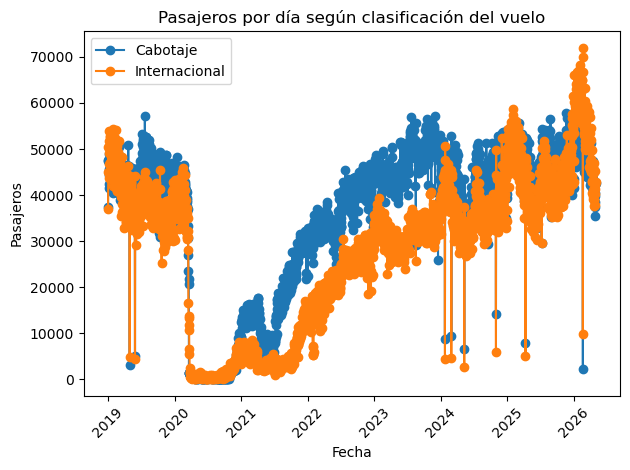

In [57]:
pasajeros_por_mes = conectividad.groupby(['fecha', 'Clasificacion'])['Pasajeros'].sum().reset_index()

plt.figure()
for clasificacion, datos in pasajeros_por_mes.groupby('Clasificacion'):
    plt.plot(datos['fecha'], datos['Pasajeros'], marker='o', label=clasificacion)

plt.title('Pasajeros por día según clasificación del vuelo')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

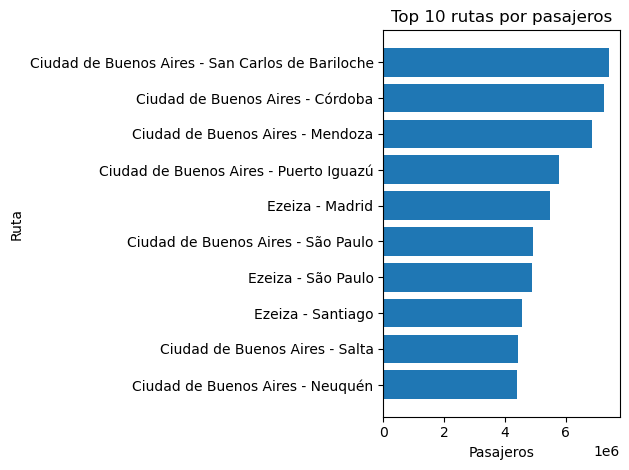

In [58]:
top_10_rutas = top_rutas.sort_values('pasajeros', ascending=False).head(10).sort_values('pasajeros')

plt.figure()
plt.barh(top_10_rutas['Ruta'], top_10_rutas['pasajeros'])
plt.title('Top 10 rutas por pasajeros')
plt.xlabel('Pasajeros')
plt.ylabel('Ruta')
plt.tight_layout()
plt.show()
plt.close()


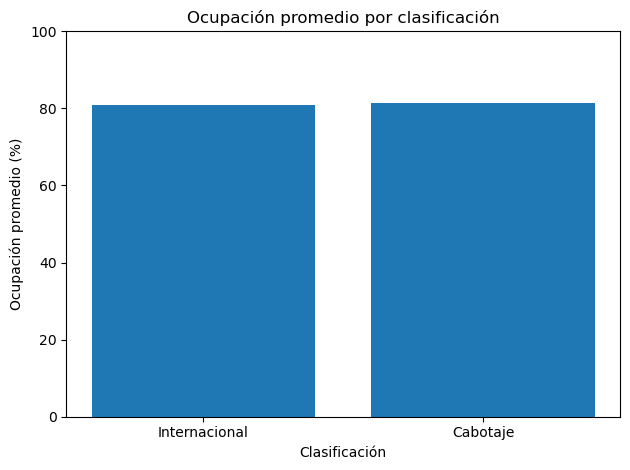

In [59]:
ocupacion_por_clase = conectividad.groupby('Clasificacion')['ocupacion'].mean().sort_values() * 100

plt.figure()
plt.bar(ocupacion_por_clase.index, ocupacion_por_clase.values)
plt.title('Ocupación promedio por clasificación')
plt.xlabel('Clasificación')
plt.ylabel('Ocupación promedio (%)')
plt.ylim(0, max(100, ocupacion_por_clase.max() + 10))
plt.tight_layout()
plt.show()
plt.close()
